# Resolution Reduction of Spatial Omics Data
## In converting Spatial Omics Data into an invertible language, we found that the prominence of empty space (grid coordinates lacking a cell with its centroid at that position) led to the training data for our LLM becoming dominated by the presence of tokenized empty spaces. The prominence of these tokenized spaces potentially diminishes the efficacy of the training process, motivating the creation of a resolution reduction scheme aimed at reducing the relative frquency of these spaces.
## In this notebook, we propose a regime for decreasing the dimensions of a Spatial Omics Dataset by optimally minimizing grid resolution and mapping centroid corrdinates to the appropriate coordinates in the lower-dimensional grid.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import csv
import copy

## Load the dataset and plot an image of the first region at the intial resolution for future comparison.

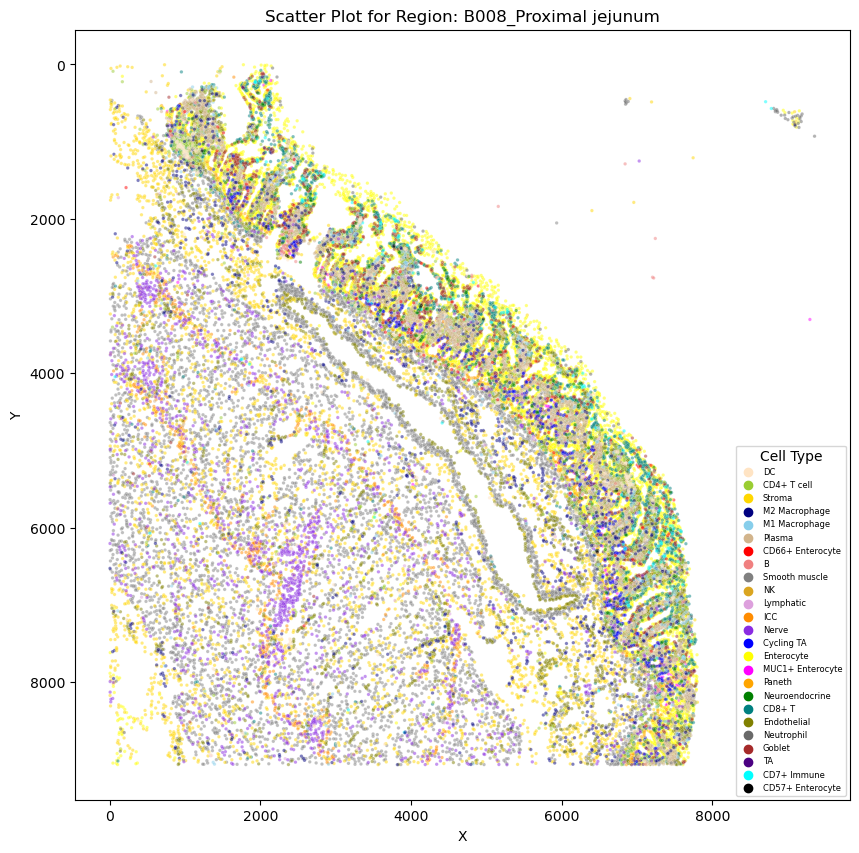

In [ ]:
df = pd.read_csv('/Users/zachrobers/Spatial_LLM/notebooks/conflict_cleaned_CODEX_HuBMAP_alldata_Dryad_merged.csv', index_col=0)
ORIGINAL_PIXEL_TO_MICROMETER = 0.377
ORIGINAL_DIMENSIONS = (9406,9070)

# Divide into Separate Arrays for Each Unique Region
grouped_by_region = df.groupby('unique_region')
first_region_name = list(grouped_by_region.groups.keys())[28] # Get the name of the first region
first_region_data = grouped_by_region.get_group(first_region_name) # Get the data associated with the first region

# Define the Colors for Each Cell Consistently with Hierarchical Neighborhoods Notebook
color_map = {
    'Cycling TA': 'blue',
    'CD66+ Enterocyte': 'red',
    'Enterocyte': 'yellow',
    'MUC1+ Enterocyte': 'magenta',
    'Paneth': 'orange',
    'Neuroendocrine': 'green',
    'Goblet': 'brown',
    'CD57+ Enterocyte': 'black',
    'Smooth muscle': 'gray',
    'M1 Macrophage': 'skyblue',
    'Stroma': 'gold',
    'Lymphatic': 'plum',
    'CD4+ T cell': 'yellowgreen',
    'Plasma': 'tan',
    'M2 Macrophage': 'navy',
    'DC': 'bisque',
    'NK': 'goldenrod',
    'Nerve': 'blueviolet',
    'ICC': 'darkorange',
    'CD8+ T': 'teal',
    'Endothelial': 'olive',
    'Neutrophil': 'dimgray',
    'TA': 'indigo',
    'B': 'lightcoral',
    'CD7+ Immune': 'cyan'
}

plt.figure(figsize=(10,10))
sns.scatterplot(data=first_region_data, x='x', y='y', hue='Cell Type', palette=color_map, alpha=0.5, s=6)
plt.gca().invert_yaxis()  # Invert the y-axis
plt.title(f'Scatter Plot for Region: {first_region_name}')  # Add title
plt.xlabel('X')  # Add x-axis label
plt.ylabel('Y')  # Add y-axis label
plt.legend(title='Cell Type', prop={'size': 6})  # Add legend with title

plt.show()


## Calculate the original proportion of coordinate pairs which have a cell with its centroid defined at that point for each unique region.

In [ ]:
region_to_initial_ratio = {} # Maps the name of the region to the initial ratio of cells to possible coordinate (x,y) pairs

for region, region_data in grouped_by_region:
    # find max_x and max_y coords
    max_x = region_data['x'].max()
    max_y = region_data['y'].max()

    # Add to ratio map
    total_possible_coord_pairs = (max_x + 1) * (max_y + 1)
    region_cells = len(region_data) # number of cells in region = number of rows in region
    initial_ratio = region_cells / total_possible_coord_pairs
    region_to_initial_ratio[region] = initial_ratio

print(region_to_initial_ratio)


{'B004_Ascending': 0.00024190534408656222, 'B004_Descending': 0.00034924043983740143, 'B004_Descending - Sigmoid': 0.0002916563547555109, 'B004_Duodenum': 0.0005092209170376519, 'B004_Ileum': 0.0003141401606833903, 'B004_Mid-jejunum': 0.0004224378421804238, 'B004_Proximal Jejunum': 0.00034199804556138674, 'B004_Transverse': 0.00038542897304829694, 'B005_Ascending': 0.00020373636488455783, 'B005_Descending': 0.000600696787639218, 'B005_Descending - Sigmoid': 0.00016671823754952424, 'B005_Duodenum': 0.00027584353057201293, 'B005_Ileum': 0.00020659145265235416, 'B005_Mid-jejunum': 0.0010057801622764145, 'B005_Proximal Jejunum': 0.0004484424908834604, 'B005_Transverse': 0.0003897447753823586, 'B006_Ascending': 0.0004483989552752108, 'B006_Descending': 0.00027052579483045436, 'B006_Descending - Sigmoid': 0.0002860497272381448, 'B006_Duodenum': 0.0006549561995111806, 'B006_Ileum': 0.00104705333169063, 'B006_Mid-jejunum': 0.00041278591474287263, 'B006_Proximal Jejunum': 0.000481269875091789, 

In [ ]:
# uniqueness test- delete later
region_num = 0
for region, region_data in grouped_by_region:
    if region == "B008_Proximal jejunum":
        print(region_num)
        for idx, row in region_data.iterrows():
            if (row['x'] == 3834.0 and row['y'] == 2099.0):
                print(f"found at index: {idx}")
                print(row)
    region_num = region_num + 1

28
found at index: -0.0460265092551708
SOX9                         -0.073666
MUC1                           -0.1154
CD31                          -0.20374
Synapto                      -0.107378
CD49f                        -0.318018
                          ...         
NeighInd_sub                Epithelial
Community          CD8+ T Enriched IEL
Major Community             Epithelial
Tissue Segment                  Mucosa
Tissue Unit                     Mucosa
Name: -0.0460265092551708, Length: 73, dtype: object


## Functions to find optimal grid spacing and map current (x,y) pairs to (x,y) pairs on this new grid
### We deploy a dictionary to map cell coordinates to their new coordinate pair for each region. If there is a conflict (i.e. more cells than one which map to the same corrdinate pair), we increment the size of the grid. We repeat this process until we find a grid size which does not result in any conflicts.

In [ ]:
# Averages the x and y coordinates of the passing and failing dimensions
def calculate_dimensions(passing, failing):
    x_p, y_p = passing
    x_f, y_f = failing

    x_new = round((x_p + x_f) * 0.5)
    y_new = round((y_p + y_f) * 0.5)

    new = (x_new,y_new)

    if (new == failing):
        return passing

    return new


In [ ]:
# Scales a coordinate pair from the grid with the original dimensions to the new dimensions
def compute_new_coord_pair(coord_pair, dimensions, original_dimensions):
    c_1, c_2 = coord_pair
    x,y = dimensions
    x_i, y_i = original_dimensions

    x_factor = x / x_i
    y_factor = y / y_i

    return (round(c_1 * x_factor), round(c_2 * y_factor))


In [ ]:
# Returns the df at the optimally reduced dimensions. Cell corrdinates are changed but all other data remains the same.
def reduce_dimensions(df_initial, original_dimensions):
    failing_dimensions = (1, 1) # Failing dimensions represent the most recent dimensions to run successfully without conflict- Start at (1, 1) to avoid divide by 0 in increment_dimensions
    passing_dimensions = original_dimensions
    dimensions = failing_dimensions
    restart_outer_loop = True

    # Loop executes as long as calculate_dimensions doesn't repeatedly return the same dimensions. At this point, we know we have found the optimal dimensions
    while (dimensions != passing_dimensions):

        # update which dimension
        if restart_outer_loop:
            failing_dimensions = dimensions
        else:
            passing_dimensions = dimensions

        dimensions = calculate_dimensions(passing_dimensions, failing_dimensions)
        print(f"Current dimensions: {dimensions}")


        df = copy.deepcopy(df_initial) # make a copy of the initial data to convert to new coordinates
        grouped_by_region = df.groupby('unique_region')
        restart_outer_loop = False # flag to indicate whether to restart the while loop

        coords = set()
        for region_name, region_data in grouped_by_region:
            coords.clear() # all of the coordinates with a cell at that coordinate thus far- we use a set for O(1)

            # iterate through rows in original data set for the region
            for idx, row in region_data.iterrows():
                x = row['x']
                y = row['y']
                coord_pair = (x,y)
                # compute the new cell coordinates for the reduced grid space
                new_coord_pair = compute_new_coord_pair(coord_pair, dimensions, original_dimensions)

                # check to see if there is a conflict
                if (new_coord_pair in coords and coord_pair != (4915.0, 7055.0)):
                    # advance the while loop to increment the dimensions
                    print(f"failing coordinate pair: {new_coord_pair}, scaled from {coord_pair} in region {region_name}")
                    restart_outer_loop = True
                    break
                else:
                    x_n, y_n = new_coord_pair
                    df.at[idx, 'x'] = x_n
                    df.at[idx, 'y'] = y_n
                    coords.add(new_coord_pair)

            if(restart_outer_loop):
                break

            print(f"successfully reduced region {region_name}")

    return df, dimensions


## Convert the data to have lower resolution using the previously defined functions

In [ ]:
new_df, new_dimensions = reduce_dimensions(df, ORIGINAL_DIMENSIONS)
print(f"The new dimensions are: {new_dimensions}")

## Graph the same region to see how it compares to the graph at the original resolution

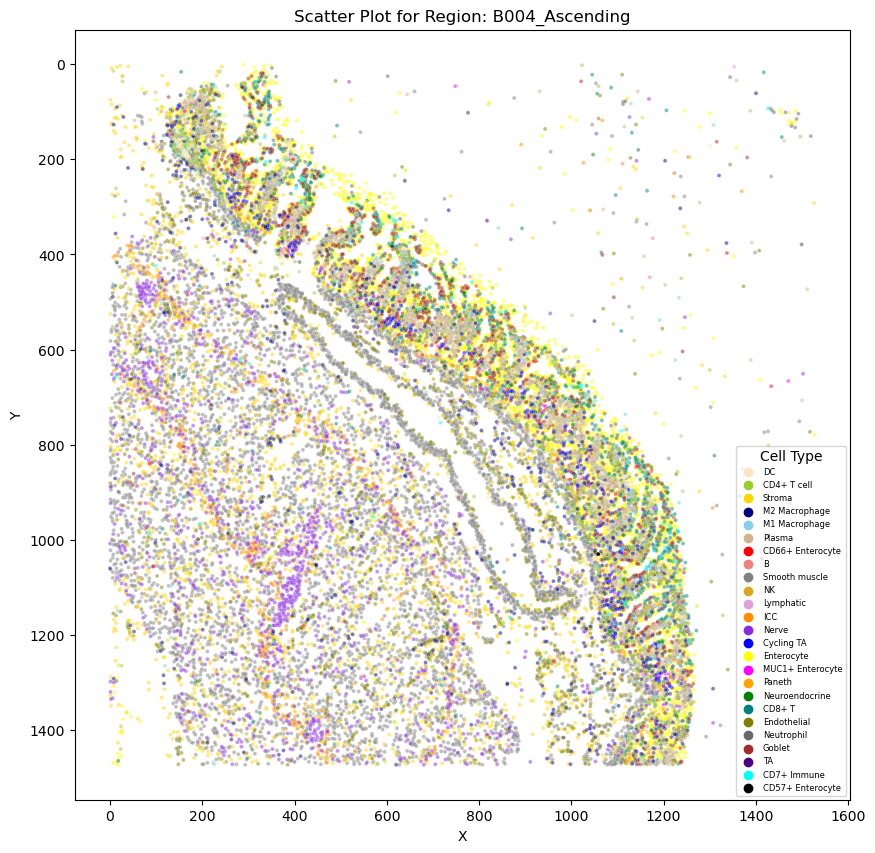

In [ ]:
# Divide into Separate Arrays for Each Unique Region
new_grouped_by_region = new_df.groupby('unique_region')
new_first_region_name = list(new_grouped_by_region.groups.keys())[0] # Get the name of the first region
new_first_region_data = new_grouped_by_region.get_group(first_region_name) # Get the data associated with the first region

# Define the Colors for Each Cell Consistently with Hierarchical Neighborhoods Notebook
color_map = {
    'Cycling TA': 'blue',
    'CD66+ Enterocyte': 'red',
    'Enterocyte': 'yellow',
    'MUC1+ Enterocyte': 'magenta',
    'Paneth': 'orange',
    'Neuroendocrine': 'green',
    'Goblet': 'brown',
    'CD57+ Enterocyte': 'black',
    'Smooth muscle': 'gray',
    'M1 Macrophage': 'skyblue',
    'Stroma': 'gold',
    'Lymphatic': 'plum',
    'CD4+ T cell': 'yellowgreen',
    'Plasma': 'tan',
    'M2 Macrophage': 'navy',
    'DC': 'bisque',
    'NK': 'goldenrod',
    'Nerve': 'blueviolet',
    'ICC': 'darkorange',
    'CD8+ T': 'teal',
    'Endothelial': 'olive',
    'Neutrophil': 'dimgray',
    'TA': 'indigo',
    'B': 'lightcoral',
    'CD7+ Immune': 'cyan'
}

plt.figure(figsize=(10,10))
sns.scatterplot(data=new_first_region_data, x='x', y='y', hue='Cell Type', palette=color_map, alpha=0.5, s=8)
plt.gca().invert_yaxis()  # Invert the y-axis
plt.title(f'Scatter Plot for Region: {new_first_region_name}')  # Add title
plt.xlabel('X')  # Add x-axis label
plt.ylabel('Y')  # Add y-axis label
plt.legend(title='Cell Type', prop={'size': 6})  # Add legend with title

plt.show()


## Calculate ratio improvements for each region- By what factor did the relative percentage of cells to grid points improve?

In [ ]:
region_to_final_ratio = {}
for region, region_data in new_grouped_by_region:

    # find max_x and max_y coords
    max_x = region_data['x'].max()
    max_y = region_data['y'].max()

    # Add to ratio map
    total_possible_coord_pairs = (max_x + 1) * (max_y + 1)
    region_cells = len(region_data) # number of cells in region = number of rows in region
    initial_ratio = region_cells / total_possible_coord_pairs
    region_to_final_ratio[region] = initial_ratio

# Create a table to display the intial ratio, final ratio, and percent improvement for each region
data = []
for region in region_to_initial_ratio:
    initial_ratio = region_to_initial_ratio[region]
    final_ratio = region_to_final_ratio.get(region, 0)  # Use 0 if the region is not in final ratios
    percent_increase = ((final_ratio - initial_ratio) / initial_ratio) * 100 if initial_ratio != 0 else 0
    data.append({
        'region_name': region,
        'initial_ratio': initial_ratio,
        'final_ratio': final_ratio,
        'percent_increase': percent_increase
    })

# Convert to DataFrame
df_ratios = pd.DataFrame(data)

# Display the table
print(df_ratios)

                  region_name  initial_ratio  final_ratio  percent_increase
0              B004_Ascending       0.000242     0.009165       3688.658608
1             B004_Descending       0.000349     0.013232       3688.658608
2   B004_Descending - Sigmoid       0.000292     0.010862       3624.218789
3               B004_Duodenum       0.000509     0.018961       3623.502534
4                  B004_Ileum       0.000314     0.011488       3557.093459
..                        ...            ...          ...               ...
61           B012_Mid jejunum       0.000787     0.029820       3688.240941
62      B012_Proximal jejunum       0.000380     0.014406       3688.395802
63                 B012_Right       0.000299     0.011262       3671.443865
64               B012_Sigmoid       0.000602     0.022789       3687.435532
65                 B012_Trans       0.000325     0.012298       3688.255859

[66 rows x 4 columns]


## Convert the new dataframe to a CSV

In [ ]:
csv_file_path = 'conflict_cleaned_and_dimensions_reduced_CODEX_HuBMAP_alldata_Dryad_merged.csv'
new_df.to_csv(csv_file_path, index=False)
print(f"DataFrame saved as {csv_file_path}")

DataFrame saved as conflict_cleaned_and_dimensions_reduced_CODEX_HuBMAP_alldata_Dryad_merged.csv
